# Hisobot — Metall nuqsoni aniqlash

CNN va baseline natijalarini ko'rsatadi. Standart rejim: `RUN_TRAINING = False` — faqat saqlangan natijalar.

In [ ]:
RUN_TRAINING = False

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from IPython.display import Image as IPImage, display

ROOT = Path.cwd()
if not (ROOT / "config" / "settings.yaml").exists():
    if (ROOT.parent / "config" / "settings.yaml").exists():
        ROOT = ROOT.parent
    else:
        raise FileNotFoundError(
            "config/settings.yaml topilmadi. Notebookni loyiha ildizidan yoki notebooks/ papkasidan oching."
        )

sys.path.insert(0, str(ROOT))

from src.utils import get_device, load_config, load_json, resolve_path

cfg = load_config(ROOT / "config" / "settings.yaml")
device = get_device(cfg["training"]["device"])

print("Project root:", ROOT)
print("Device:", device)
print("RUN_TRAINING:", RUN_TRAINING)

Project root: C:\Users\anaso\Desktop\AI assignment
Device: cuda
RUN_TRAINING: False


## O'qitish tarixi (CNN)

,epoch,train_loss,train_acc,val_loss,val_acc,seconds,batch_size
15,16,0.22715,0.92448,0.24014,0.91941,193.79,16
16,17,0.22742,0.92428,0.19524,0.94048,191.85,16
17,18,0.21760,0.92311,0.18635,0.93956,193.90,16
18,19,0.21821,0.92409,0.30323,0.89835,197.47,16
19,20,0.22429,0.92154,0.18671,0.93498,188.46,16


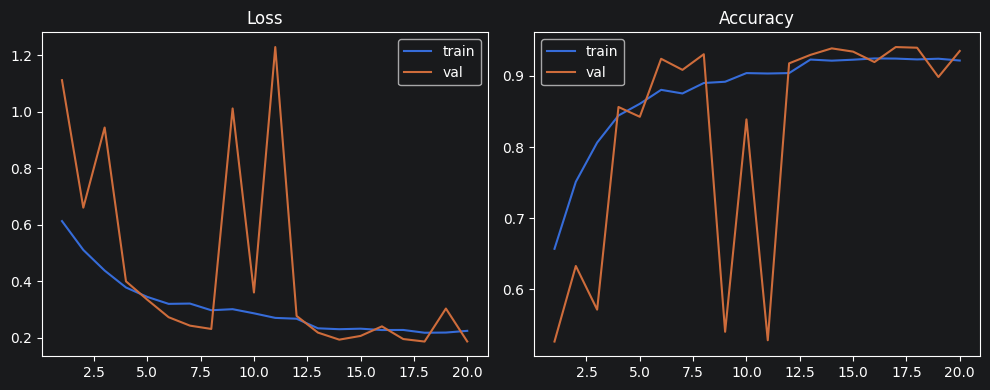

In [ ]:
hist_path = resolve_path(cfg["paths"]["cnn_history"])
if hist_path.exists():
    history = load_json(hist_path)
    df_hist = pd.DataFrame(history)
    display(df_hist.tail())
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(df_hist["epoch"], df_hist["train_loss"], label="train")
    ax[0].plot(df_hist["epoch"], df_hist["val_loss"], label="val")
    ax[0].set_title("Loss")
    ax[0].legend()
    ax[1].plot(df_hist["epoch"], df_hist["train_acc"], label="train")
    ax[1].plot(df_hist["epoch"], df_hist["val_acc"], label="val")
    ax[1].set_title("Accuracy")
    ax[1].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Tarix topilmadi. Avval `python scripts/train.py` ishga tushiring yoki RUN_TRAINING=True qiling.")

## Test metrikalari va confusion matrix

,Metric,Value
0,Accuracy,0.934126
1,Precision,0.935605
2,Recall,0.934126
3,F1 (weighted),0.933951



Klass bo'yicha:


,class,precision,recall,f1-score,support
0,defect,0.913115,0.967014,0.939292,576.0
1,normal,0.960663,0.897485,0.928000,517.0


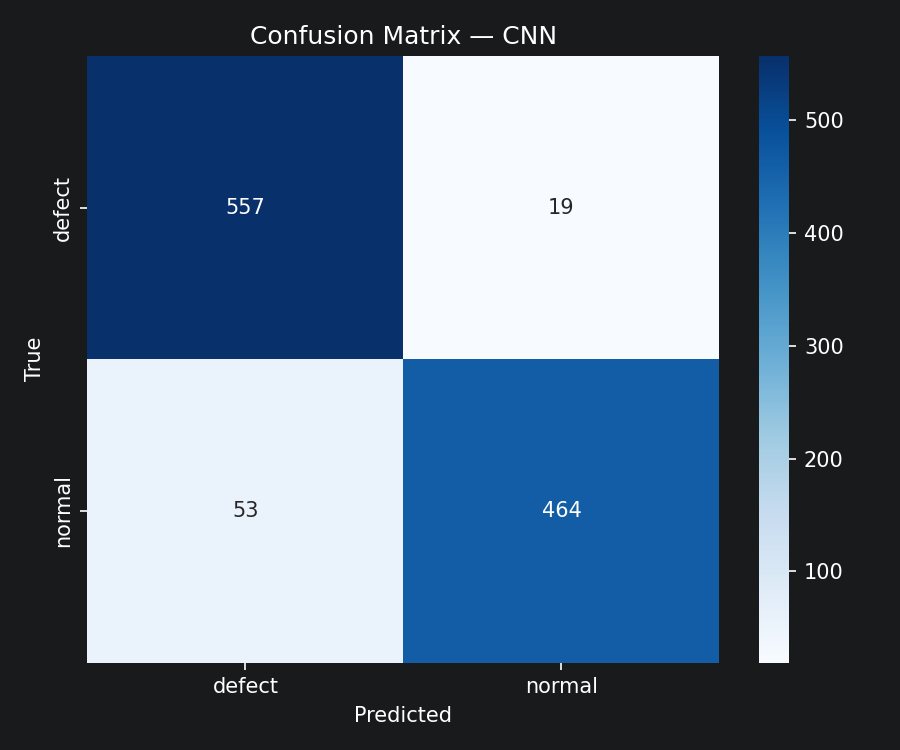

In [ ]:
metrics_path = resolve_path(cfg["paths"]["test_metrics"])
cm_path = resolve_path(cfg["paths"]["confusion_matrix"])

if metrics_path.exists():
    m = load_json(metrics_path)
    summary = pd.DataFrame(
        {
            "Metric": ["Accuracy", "Precision", "Recall", "F1 (weighted)"],
            "Value": [m.get("accuracy"), m.get("precision"), m.get("recall"), m.get("f1_weighted")],
        }
    )
    display(summary)

    report = m.get("classification_report", {})
    per_class = [
        {"class": cls, **report[cls]}
        for cls in cfg["data"]["classes"]
        if cls in report
    ]
    if per_class:
        print("\nKlass bo'yicha:")
        display(pd.DataFrame(per_class))
else:
    print("Test metrikalari topilmadi. `python scripts/evaluate.py` ishga tushiring.")

if cm_path.exists():
    display(IPImage(filename=str(cm_path)))
else:
    print("Confusion matrix rasmi topilmadi.")

## Tuning va baseline taqqoslash

In [ ]:
comparisons = [
    ("Hyperparameter tuning", resolve_path(cfg["paths"]["tuning_comparison"])),
    ("CNN vs baseline", resolve_path(cfg["paths"]["baseline_comparison"])),
]

for title, path in comparisons:
    print(f"\n=== {title} ===")
    if path.exists():
        display(pd.read_csv(path))
    else:
        print(f"Fayl topilmadi: {path}")
        if "tuning" in str(path):
            print("  → `python scripts/run_tuning.py`")
        else:
            print("  → `python scripts/train_baseline.py`")


=== Hyperparameter tuning ===
Fayl topilmadi: C:\Users\anaso\Desktop\AI assignment\results\tuning\comparison.csv
  → `python scripts/run_tuning.py`

=== CNN vs baseline ===
Fayl topilmadi: C:\Users\anaso\Desktop\AI assignment\results\baseline\comparison.csv
  → `python scripts/train_baseline.py`


## CNN model (checkpoint)

In [ ]:
from src.model import build_cnn

ckpt_path = resolve_path(cfg["paths"]["cnn_checkpoint"])
if ckpt_path.exists():
    state = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = build_cnn(len(cfg["data"]["classes"]), cfg["training"]["dropout"]).to(device)
    model.load_state_dict(state["model_state"])
    model.eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Checkpoint: {ckpt_path.name}")
    print(f"Eng yaxshi epoch: {state.get('epoch', '?')}")
    print(f"Val accuracy (saqlangan): {state.get('val_acc', '?')}")
    print(f"Parametrlar: {n_params:,}")
else:
    print("Checkpoint topilmadi. `python scripts/train.py` ishga tushiring.")

Checkpoint: cnn_best.pth
Eng yaxshi epoch: 16
Val accuracy (saqlangan): ?
Parametrlar: 422,530


## Feature maps (Grad-CAM)

Modelning diqqat markazidagi (Grad-CAM) issiqlik xaritalari:
  feature_map_defect.png


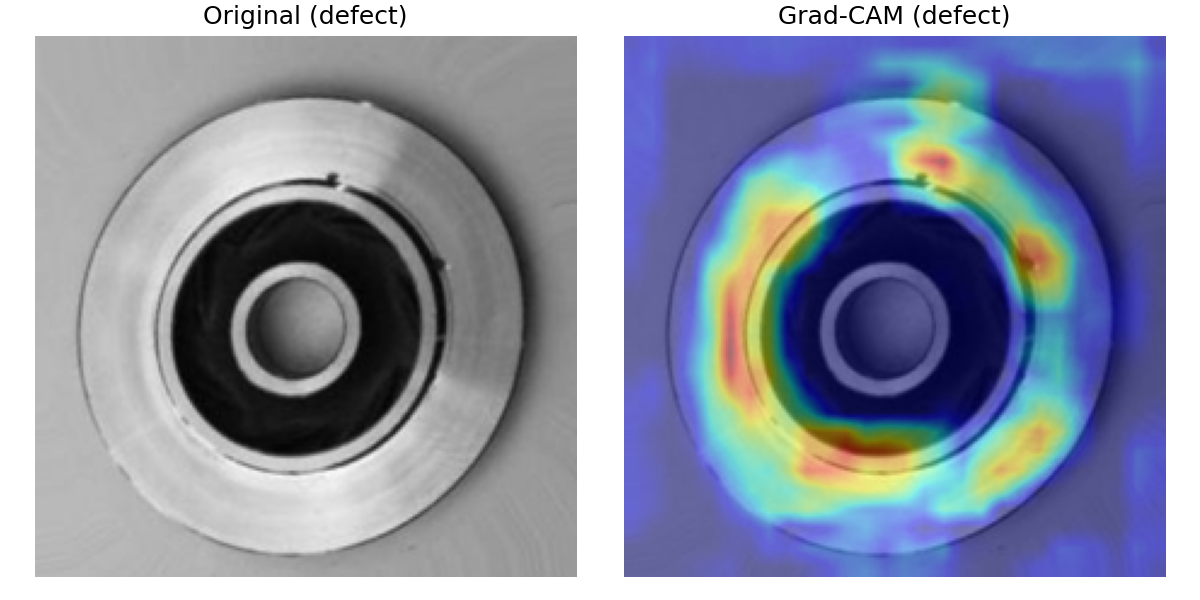

  feature_map_normal.png


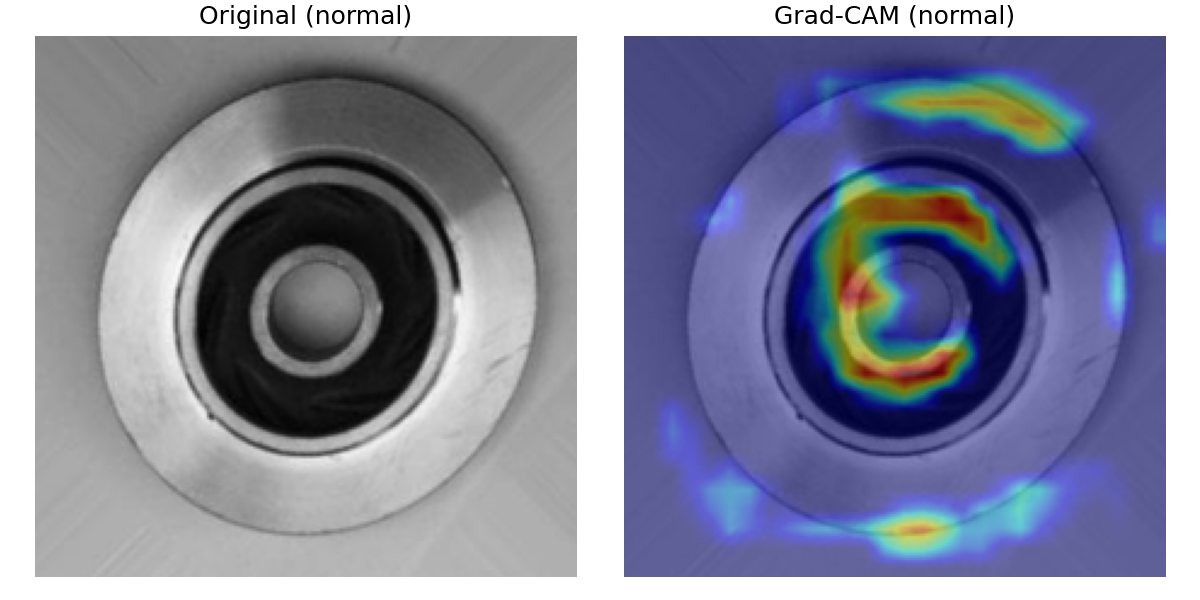

In [ ]:
fm_dir = resolve_path(cfg["paths"]["feature_maps_dir"])
pngs = sorted(fm_dir.glob("*.png")) if fm_dir.exists() else []

if pngs:
    print("Modelning diqqat markazidagi (Grad-CAM) issiqlik xaritalari:")
    for png in pngs:
        print(f"  {png.name}")
        display(IPImage(filename=str(png)))
else:
    print("Feature maps topilmadi. `python scripts/evaluate.py` ishga tushiring.")

## Ixtiyoriy: to'liq o'qitish (notebook ichida)

Faqat `RUN_TRAINING = True` qilganda ishlaydi.

In [ ]:
if RUN_TRAINING:
    from src.trainer import train_cnn
    from src.utils import set_seed

    set_seed(cfg.get("random_seed", 42))
    train_cnn(cfg, epochs=3)
else:
    print("O'qitish o'tkazib yuborildi (RUN_TRAINING=False).")

O'qitish o'tkazib yuborildi (RUN_TRAINING=False).
